# Robustness: Does OFI Signal Hold Up?

The first notebook found OFI predicted 5-second forward returns on a **2-hour** 
sample, with the effect concentrated in low-volatility regimes. Two hours is a 
very small sample, so I deployed the C++ collector to EC2 and captured
**20.5 days** of continuous BTC-USD L2 data (~28M book snapshots).

This notebook re-tests the finding on that dataset, across **regimes**,
**individual days**, and **multiple forecast horizons**.

In [35]:
import sys, glob
from pathlib import Path

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

from src.ofi_study.analysis import build_features_many, regress, directional_accuracy

# categorical palette: colorblind-safe blue/orange (validated, CVD dE 24.7)
LOW, HIGH = "#2a78d6", "#eb6834"
INK, MUTED = "#0b0b0b", "#52514e"

print("ok")

ok


In [36]:
cache = project_root / "data" / "features_3wk.parquet"

if cache.exists():
    frame = pd.read_parquet(cache)
else:
    paths = sorted(glob.glob(str(project_root / "data" / "ec2" / "*.parquet")))
    frame = build_features_many(paths)
    frame.to_parquet(cache)

print(f"{len(frame):,} one-second observations")
print(f"{frame.index[0]} -> {frame.index[-1]} ({frame.index[-1] - frame.index[0]})")
frame["regime"].value_counts()

1,772,112 one-second observations
2026-08-09 09:41:58+00:00 -> 2026-08-29 21:57:09+00:00 (20 days 12:15:11)


regime
high    1180588
low      591524
Name: count, dtype: int64

## Full sample: overall and by regime

In [37]:
def summarize(label, f):
    r = regress(f)
    acc, base = directional_accuracy(f)
    return {
        "sample": label,
        "n": len(f),
        "coef": r.params["ofi"],
        "t_HAC": r.tvalues["ofi"],
        "r_squared": r.rsquared,
        "dir_acc": acc,
        "baseline": base,
        "edge_pp": (acc - base) * 100,
    }

results = pd.DataFrame([
    summarize("all", frame),
    summarize("low vol", frame[frame["regime"] == "low"]),
    summarize("high vol", frame[frame["regime"] == "high"]),
]).set_index("sample")

results.style.format({
    "n": "{:,}",
    "coef": "{:.2e}",
    "t_HAC": "{:.2f}",
    "r_squared": "{:.4f}",
    "dir_acc": "{:.3f}",
    "baseline": "{:.3f}",
    "edge_pp": "{:.1f}",
})

,n,coef,t_HAC,r_squared,dir_acc,baseline,edge_pp
sample,,,,,,,
all,"1,772,112",3.81e-06,3.04,0.0012,0.566,0.511,5.4
low vol,"591,524",1.02e-05,18.71,0.0079,0.590,0.535,5.5
high vol,"1,180,588",3.54e-06,2.91,0.0010,0.560,0.506,5.4


## Robustness across forecast horizons

A signal that only works at one arbitrary horizon is suspect. Here the same
regression is run at 1, 5, 10, and 30 seconds.

In [38]:
log_mid = np.log(frame["mid"])

rows = []
for h in [1, 5, 10, 30]:
    f = frame.assign(fwd_ret=log_mid.shift(-h) - log_mid).dropna(subset=["fwd_ret"])
    for regime in ["low", "high"]:
        g = f[f["regime"] == regime]
        r = sm.OLS(g["fwd_ret"], sm.add_constant(g["ofi"])).fit(
            cov_type="HAC", cov_kwds={"maxlags": h})
        acc, base = directional_accuracy(g)
        rows.append({"horizon_s": h, "regime": regime,
                     "t_HAC": r.tvalues["ofi"], "r_squared": r.rsquared,
                     "edge_pp": (acc - base) * 100})

horizons = pd.DataFrame(rows)
horizons.style.format({"t_HAC": "{:.2f}", "r_squared": "{:.4f}", "edge_pp": "{:.1f}"})

,horizon_s,regime,t_HAC,r_squared,edge_pp
0,1,low,21.47,0.0089,10.2
1,1,high,3.10,0.0019,10.5
2,5,low,18.71,0.0079,5.5
3,5,high,2.91,0.0010,5.4
4,10,low,18.45,0.0065,3.7
5,10,high,2.77,0.0006,3.6
6,30,low,17.00,0.0033,1.6
7,30,high,2.32,0.0002,1.8


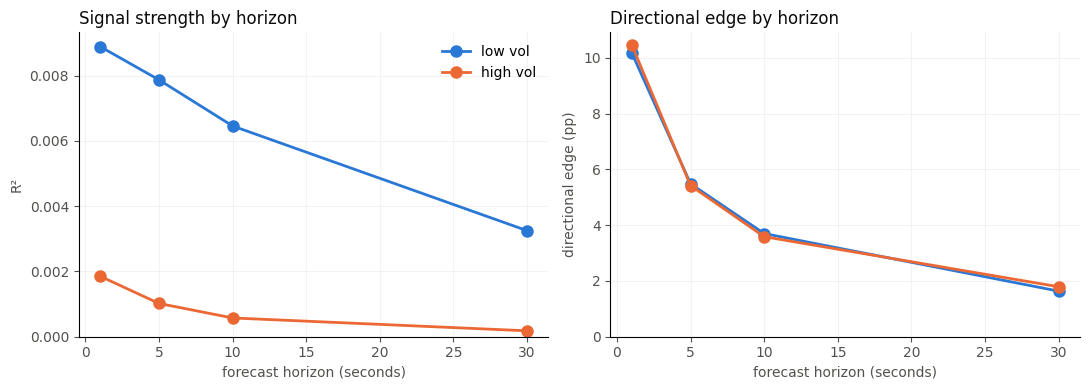

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, (col, label) in zip(axes, [("r_squared", "R²"),
                                   ("edge_pp", "directional edge (pp)")]):
    for regime, color in [("low", LOW), ("high", HIGH)]:
        d = horizons[horizons["regime"] == regime]
        ax.plot(d["horizon_s"], d[col], marker="o", markersize=8,
                linewidth=2, color=color, label=f"{regime} vol")
    ax.set_xlabel("forecast horizon (seconds)", color=MUTED)
    ax.set_ylabel(label, color=MUTED)
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.15)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(colors=MUTED)

axes[0].set_title("Signal strength by horizon", color=INK, loc="left")
axes[1].set_title("Directional edge by horizon", color=INK, loc="left")
axes[0].legend(frameon=False)
plt.tight_layout()


## Day-by-day: does the regime effect replicate?

Pooling 20 days can hide the possibility that one unusual session drives
everything. Here each day is fit separately.

In [43]:
frame["day"] = frame.index.date

rows = []
for day, g in frame.groupby("day"):
    lo, hi = g[g["regime"] == "low"], g[g["regime"] == "high"]
    if len(lo) < 2000 or len(hi) < 2000:
        continue
    rl, rh = regress(lo), regress(hi)
    rows.append({"day": day, "n": len(g),
                 "t_low": rl.tvalues["ofi"], "t_high": rh.tvalues["ofi"],
                 "r2_low": rl.rsquared, "r2_high": rh.rsquared})

daily = pd.DataFrame(rows).set_index("day")
daily["low_wins"] = daily["r2_low"] > daily["r2_high"]
print(f"low-vol R² higher on {daily['low_wins'].sum()}/{len(daily)} days")
print(f"OFI significant (|t|>2) in low vol on {(daily['t_low'].abs()>2).sum()}/{len(daily)} days")

daily.style.format({"n": "{:,}", "t_low": "{:.2f}", "t_high": "{:.2f}",
                    "r2_low": "{:.4f}", "r2_high": "{:.4f}"})

low-vol R² higher on 13/17 days
OFI significant (|t|>2) in low vol on 17/17 days


,n,t_low,t_high,r2_low,r2_high,low_wins
day,,,,,,
2026-08-09,"51,482",10.03,7.95,0.0149,0.0135,True
2026-08-10,"86,400",4.65,11.23,0.0035,0.0091,False
2026-08-11,"86,400",4.47,6.96,0.0066,0.0033,True
2026-08-12,"86,400",4.69,8.88,0.0049,0.0030,True
2026-08-13,"86,400",2.67,8.93,0.0035,0.0053,False
2026-08-14,"86,400",7.82,10.65,0.0103,0.0071,True
2026-08-15,"86,400",15.58,2.56,0.0111,0.0079,True
2026-08-16,"86,400",8.14,5.65,0.0133,0.0135,False
2026-08-17,"86,400",6.01,9.87,0.0093,0.0090,True


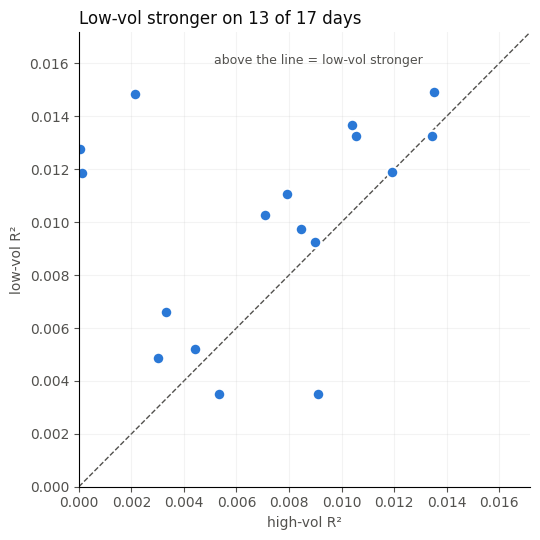

In [44]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))

lim = daily[["r2_low", "r2_high"]].to_numpy().max() * 1.15
ax.plot([0, lim], [0, lim], color=MUTED, linewidth=1, linestyle="--", zorder=1)
ax.scatter(daily["r2_high"], daily["r2_low"], s=70, color=LOW,
           edgecolor="white", linewidth=1.5, zorder=2)

ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_xlabel("high-vol R²", color=MUTED)
ax.set_ylabel("low-vol R²", color=MUTED)
ax.set_title(f"Low-vol stronger on {daily['low_wins'].sum()} of {len(daily)} days",
             color=INK, loc="left")
ax.text(lim * 0.30, lim * 0.93, "above the line = low-vol stronger",
        color=MUTED, fontsize=9)
ax.grid(alpha=0.15)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(colors=MUTED)
plt.tight_layout()

## Findings

Accross **20.5 days / 1.77 M one-second observations** of BTC-USD

1. **OFI significantly predicts forward returns** - robust across 1-30s
   horizons, and significant in low-volatility periods on every single day.
2. **Predictive power is concentrated in low-volatility regimes** - R² is
   4-8x higher at every horizon, and low-vol is stronger on 13 of 17 days.
   Two of the four exceptions are effectively ties (0.0133 vs 0.0135, and
   0.0119 vs 0.0119), so only two days genuinely favour high-vol.
3. **Direction vs. magnitude split:** the directional edge is nearly identical
   accross regimes(~10pp at 1s, decaying to ~2pp at 30s), but R² differs sharply.
   OFI calls the sign equally well in both regimes; it explains far more of the
   return *magnitude* when markets are calm.
4. **The signal decays monotonically with horizon**, consistent with order-flow
   information being incorporated into price quickly.

**Note on sample size:** an earlier 2-hour sample suggested this same regime
effect, but a 16-hour sample appeared to reverse it. Only the full 20-day
dataset resolved the question - short windows were unreliable in both
directions.

**Limitations:** one asset (BTC-USD), level-1 OFI, in-sample. NExt multi-asset
replication and formal out-of-sample validation.